# Stage 3 — Performance Comparison: Neural vs Fixed Baselines

Analyses the performance and accuracy of the Stage 3 Neural LOD system (4 thresholds) and compares it against standard Fixed-Quality baselines.

**Goals**:
1. Compare 4 predicted thresholds against geometric Oracle thresholds (if available).
2. Benchmark runtime performance (CPU/GPU/FPS) against Fixed Quality presets.
3. Analyze LOD Stability over time (flickering metrics).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
print('Libraries loaded OK')

Libraries loaded OK


In [2]:
BASE_DIR = Path('../..').resolve()
EVAL_DIR = BASE_DIR / 'data' / 'Baker_Eval_3'
BASELINE_DIR = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_3' / 'Eval'
OBJECTS_FILE = BASE_DIR / 'data' / 'Baker_2' / 'lod_objects.csv'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_COLORS = {
    'neural_4thresh':     '#2196F3',
    'neural_baker_4val':  '#2196F3',
    'fixed_default':      '#4CAF50',
    'fixed_aggressive':   '#FF9800',
}
DEFAULT_COLOR = '#9C27B0'

FRAME_BUDGET_MS = 16.67 # 60 FPS

## 1. Load Data (Neural & Baselines)

In [3]:
csv_files = list(EVAL_DIR.glob('inference_eval_*.csv')) + list(BASELINE_DIR.glob('inference_eval_*.csv'))
print(f'Found {len(csv_files)} evaluation files.')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

if not dfs:
    raise FileNotFoundError("No evaluation files found.")

data = pd.concat(dfs, ignore_index=True)

# Ensure numeric columns for 4 thresholds
threshold_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
numeric_cols = ['frame', 'cpu_ms', 'gpu_ms', 'fps', 'inference_duration_ms', 'lod_bias_applied'] + threshold_cols
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(f'Loaded {len(data)} frames across {data[ "run_label" ].nunique()} runs.')
runs = sorted(data['run_label'].unique())
data.head()

Found 3 evaluation files.
Loaded 11916 frames across 3 runs.


,run_label,frame,cpu_ms,gpu_ms,fps,inference_duration_ms,predicted_t0,predicted_t1,predicted_t2,predicted_t3,...,cam_pos_z,cam_rot_x,cam_rot_y,cam_rot_z,triangle_count,visible_renderer_count,screen_coverage,draw_call_count,source_file,predicted_threshold
0,neural_4thresh,0,12.1480,7.9718,17.2973,0.11,0.154872,0.02676,0.001938,0.0,...,31.6716,3.84,164.42,0.0,1316999.0,0.0,0.5,6673.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
1,neural_4thresh,1,22.9819,7.6718,72.6692,0.11,0.154872,0.02676,0.001938,0.0,...,31.5754,3.86,164.02,0.0,1219337.0,0.0,0.5,6145.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
2,neural_4thresh,2,53.9389,7.9299,123.7623,0.11,0.154872,0.02676,0.001938,0.0,...,31.5754,3.86,163.72,0.0,1150874.0,0.0,0.5,5749.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
3,neural_4thresh,3,15.8589,7.1813,74.1790,0.11,0.154872,0.02676,0.001938,0.0,...,31.4795,3.86,163.38,0.0,1109876.0,0.0,0.5,5596.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
4,neural_4thresh,4,12.0720,7.3728,59.7997,0.11,0.154872,0.02676,0.001938,0.0,...,31.3837,3.90,162.88,0.0,1116796.0,0.0,0.5,5570.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN


## 2. Oracle Generation (Accuracy Benchmark)
Stage 3 predicts transition heights. We derive the Oracle heights based on the `optimal_lod` logic used during training.

In [4]:
df_objects = pd.read_csv(OBJECTS_FILE)
qual_map = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4}

# Parse base thresholds from objects.csv
all_thresholds = []
for t_str in df_objects['thresholds']:
    vals = [float(v) for v in str(t_str).split(';') if v.strip()]
    if len(vals) < 4: vals += [0.001] * (4 - len(vals))
    all_thresholds.append(vals[:4])
base_vector = np.mean(all_thresholds, axis=0)

def calculate_oracle_vector(optimal_lod):
    mult = qual_map.get(int(optimal_lod), 0.4)
    return base_vector * mult

# Generate ground truth for eval data if optimal_lod is present
if 'optimal_lod' in data.columns:
    oracles = np.array([calculate_oracle_vector(lod) for lod in data['optimal_lod']])
    for i in range(4):
        data[f'oracle_threshold_{i}'] = oracles[:, i]
    print("✓ Oracle thresholds generated.")
else:
    print("ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.")

ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.


## 3. Summary Performance Matrix

In [5]:
def percentile(series, p):
    return float(np.percentile(series.dropna(), p))

summary_rows = []
for run in runs:
    df = data[data['run_label'] == run]
    cpu = df['cpu_ms']
    gpu = df['gpu_ms']
    fps = df['fps']
    inf = df['inference_duration_ms'] if 'inference_duration_ms' in df.columns else pd.Series([0])
    lod = df['lod_bias_applied'] if 'lod_bias_applied' in df.columns else pd.Series([1])

    # LOD flip rate
    lod_vals = lod.values
    switches = sum(1 for i in range(1, len(lod_vals)) if abs(lod_vals[i] - lod_vals[i-1]) > 0.001)
    duration_s = len(df) / fps.mean() if fps.mean() > 0 else 1
    flip_rate = switches / duration_s if duration_s > 0 else 0

    # frames over budget
    over_budget_pct = 100 * (cpu > FRAME_BUDGET_MS).sum() / len(cpu)

    summary_rows.append({
        'run_label':         run,
        'frames':            len(df),
        'mean_cpu_ms':       round(cpu.mean(), 3),
        'p95_cpu_ms':        round(percentile(cpu, 95), 3),
        'p99_cpu_ms':        round(percentile(cpu, 99), 3),
        'mean_gpu_ms':       round(gpu.mean(), 3),
        'p95_gpu_ms':        round(percentile(gpu, 95), 3),
        'p99_gpu_ms':        round(percentile(gpu, 99), 3),
        'mean_fps':          round(fps.mean(), 2),
        'p5_fps':            round(percentile(fps, 5), 2),
        'mean_inference_ms': round(inf.mean(), 4),
        'lod_switches':      switches,
        'flip_rate_per_s':   round(flip_rate, 3),
        'over_budget_pct':   round(over_budget_pct, 1),
    })

summary = pd.DataFrame(summary_rows).set_index('run_label')
print('=== Performance Comparison Summary ===')
display(summary.T)

=== Performance Comparison Summary ===


run_label,fixed_aggressive,fixed_default,neural_4thresh
frames,4225.000,3914.000,3777.0000
mean_cpu_ms,16.666,16.666,16.7190
p95_cpu_ms,17.032,17.048,17.0980
p99_cpu_ms,17.250,17.390,19.8040
mean_gpu_ms,4.683,5.218,5.2470
p95_gpu_ms,5.657,6.402,6.7510
p99_gpu_ms,6.021,6.761,7.0570
mean_fps,60.000,60.000,60.5600
p5_fps,59.740,59.730,59.7900
mean_inference_ms,0.000,0.000,0.1189


## 4. CPU/GPU Frame Time Comparison

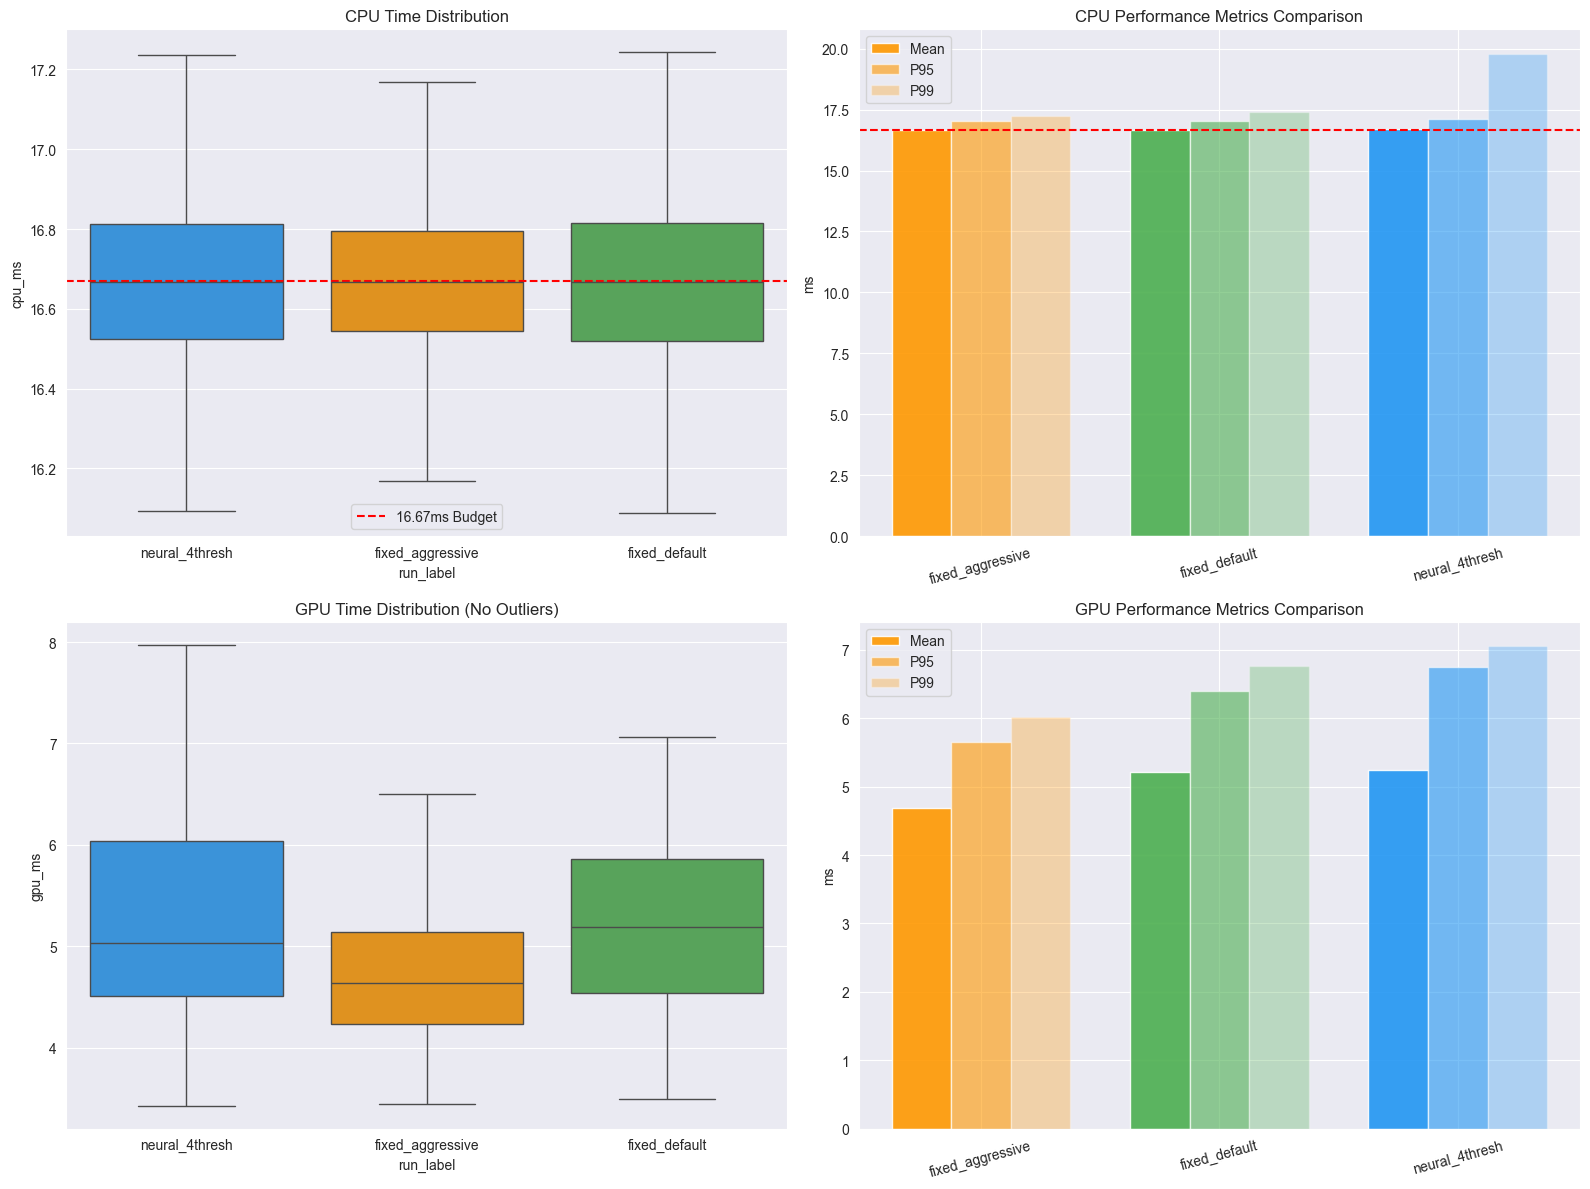

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = {label: RUN_COLORS.get(label, DEFAULT_COLOR) for label in data['run_label'].unique()}

# CPU Time Boxplots
ax = axes[0, 0]
sns.boxplot(data=data, x='run_label', y='cpu_ms', palette=palette, ax=ax, showfliers=False)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', label=f'{FRAME_BUDGET_MS}ms Budget')
ax.set_title('CPU Time Distribution')
ax.legend()

# CPU Time Comparison Bar
ax = axes[0, 1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_cpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_cpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_cpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--')
ax.set_title('CPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

# GPU Time Boxplots
ax = axes[1, 0]
sns.boxplot(data=data, x='run_label', y='gpu_ms', palette=palette, ax=ax, showfliers=False)
ax.set_title('GPU Time Distribution (No Outliers)')

# GPU Time Comparison Bar
ax = axes[1, 1]
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_gpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_gpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('GPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_comparison_matrix.png')
plt.show()

## 5. FPS Stability Comparison

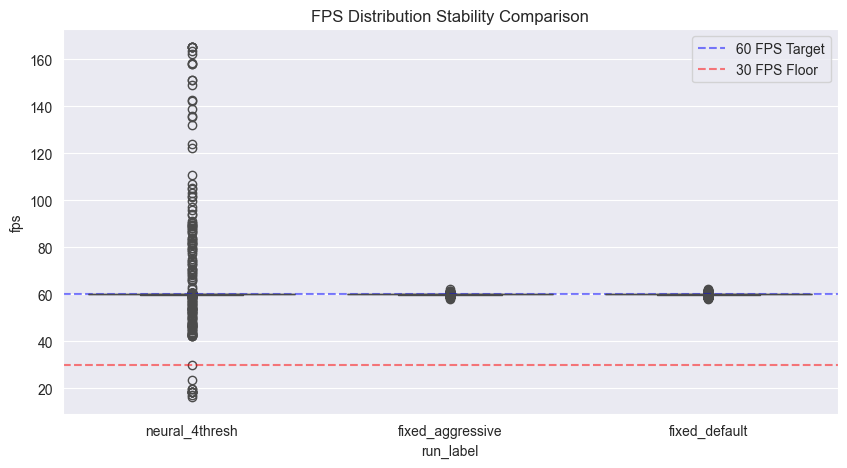

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='run_label', y='fps', palette=palette, showfliers=True)
plt.axhline(60, color='blue', linestyle='--', alpha=0.5, label='60 FPS Target')
plt.axhline(30, color='red', linestyle='--', alpha=0.5, label='30 FPS Floor')
plt.title('FPS Distribution Stability Comparison')
plt.legend()
plt.savefig(PLOTS_DIR / 'fps_comparison.png')
plt.show()

## 6. LOD Stability & Flip Frequency

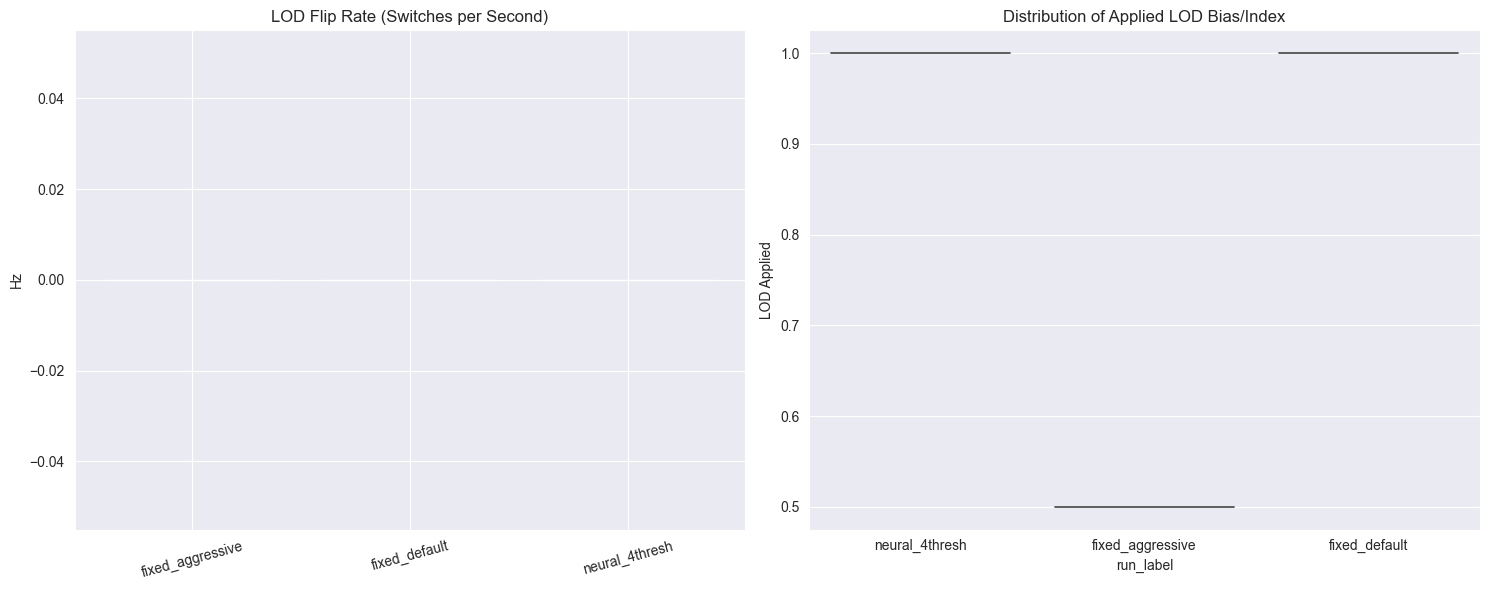

[np.float64(0.0), np.float64(0.0), np.float64(0.0)]
run_label
fixed_aggressive    0.0
fixed_default       0.0
neural_4thresh      0.0
Name: flip_rate_per_s, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Flip Rate Bar
ax = axes[0]
x = np.arange(len(runs))
rates = [summary.loc[r, 'flip_rate_per_s'] for r in runs]
ax.bar(x, rates, color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('LOD Flip Rate (Switches per Second)')
ax.set_ylabel('Hz')

# 2. Applied LOD Distribution
ax = axes[1]
sns.violinplot(data=data, x='run_label', y='lod_bias_applied', palette=palette, ax=ax)
ax.set_title('Distribution of Applied LOD Bias/Index')
ax.set_ylabel('LOD Applied')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'lod_stability_analysis.png')
plt.show()
print(rates)
print(summary['flip_rate_per_s'])

## 7. Performance Purity (CDF Plots)

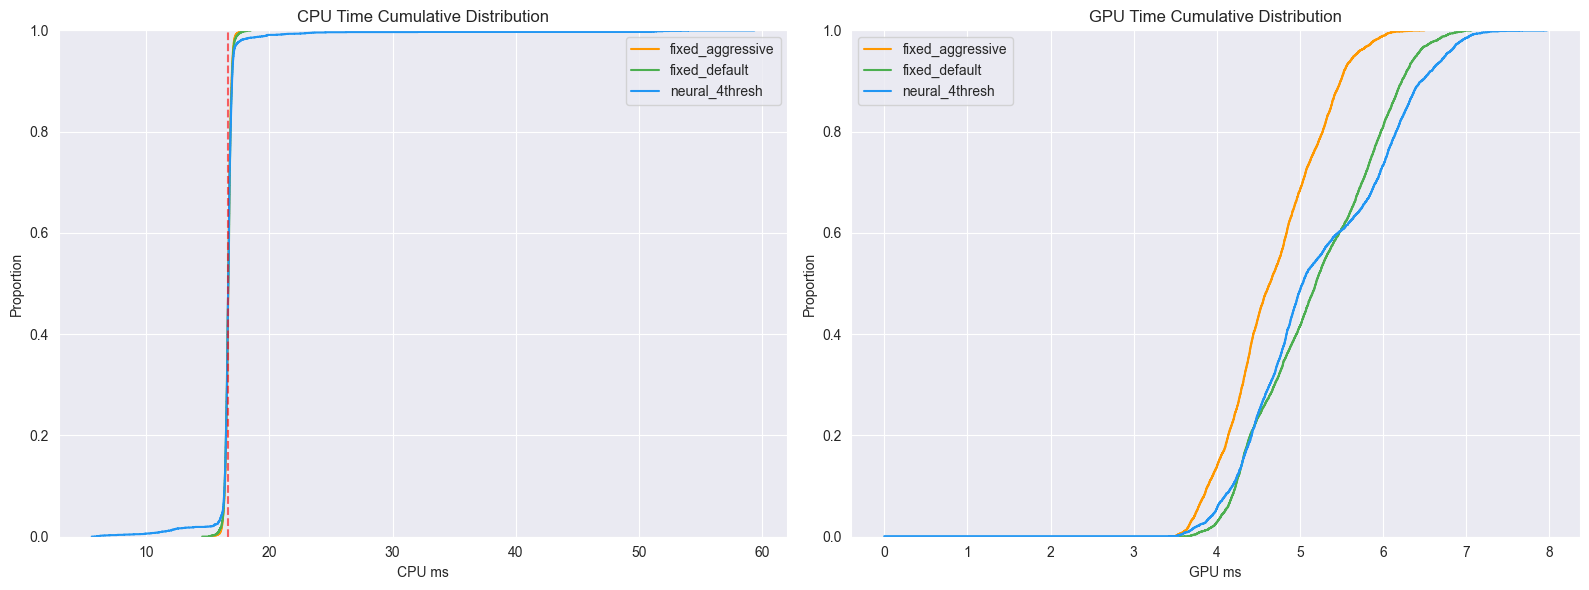

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CPU CDF
ax = axes[0]
for run in runs:
    subset = data[data['run_label'] == run]['cpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.axvline(FRAME_BUDGET_MS, color='red', linestyle='--', alpha=0.6)
ax.set_title('CPU Time Cumulative Distribution')
ax.set_xlabel('CPU ms')
ax.legend()

# GPU CDF
ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run]['gpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.set_title('GPU Time Cumulative Distribution')
ax.set_xlabel('GPU ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_cdf.png')
plt.show()

### 8. ROI Efficiency: GPU Savings vs. Model Overhead


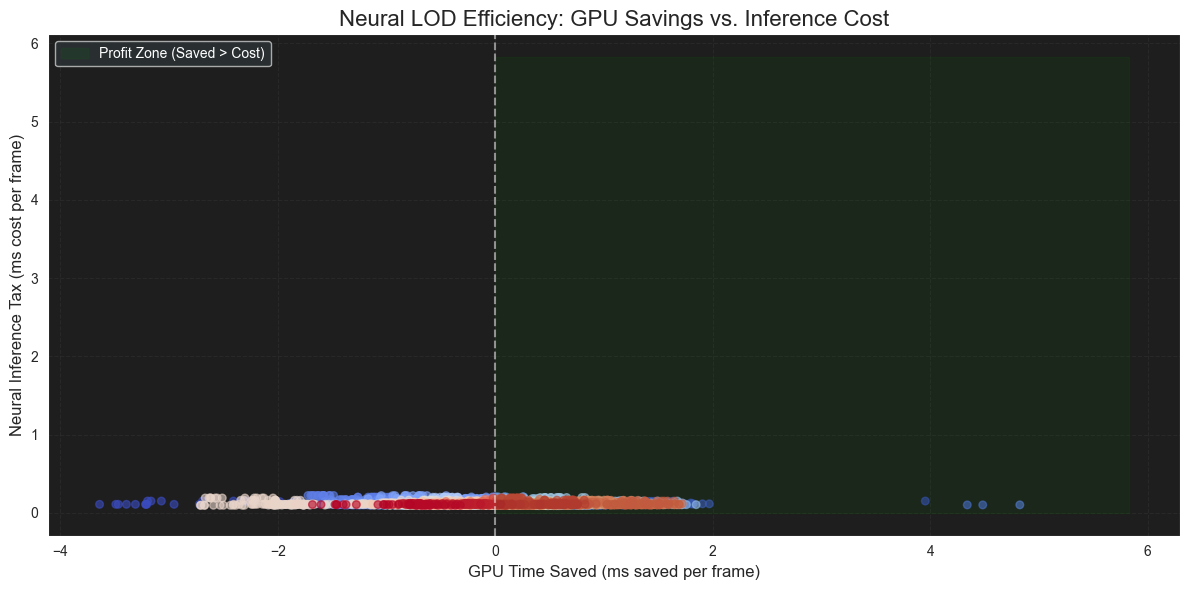

In [10]:
# Filter both runs
neural_plot = data[data['run_label'] == 'neural_4thresh'].copy()
baseline_plot = data[data['run_label'] == 'fixed_default'].copy()

if not neural_plot.empty and not baseline_plot.empty:
    # Merge on 'frame' to align camera points perfectly
    merged_roi = pd.merge(neural_plot[['frame', 'gpu_ms', 'inference_duration_ms']], 
                          baseline_plot[['frame', 'gpu_ms']], 
                          on='frame', suffixes=('_neural', '_base'))
    
    # Calculate Savings: Positive = Neural is faster than Baseline
    gpu_savings = merged_roi['gpu_ms_base'] - merged_roi['gpu_ms_neural']

    plt.figure(figsize=(12, 6))
    plt.scatter(gpu_savings, merged_roi['inference_duration_ms'], 
                c=merged_roi['frame'], cmap='coolwarm', alpha=0.6, s=30)

    plt.axvline(0, color='white', linestyle='--', alpha=0.5)
    plt.title('Neural LOD Efficiency: GPU Savings vs. Inference Cost', fontsize=16)
    plt.xlabel('GPU Time Saved (ms saved per frame)', fontsize=12)
    plt.ylabel('Neural Inference Tax (ms cost per frame)', fontsize=12)
    
    # Visual cues for ROI zones
    plt.fill_between([0, gpu_savings.max()+1], 0, [gpu_savings.max()+1, gpu_savings.max()+1], 
                     color='green', alpha=0.1, label='Profit Zone (Saved > Cost)')

    plt.gca().set_facecolor('#1E1E1E')
    plt.grid(color='#333333', linestyle='--', alpha=0.5)
    plt.legend(facecolor='#2D3436', labelcolor='white')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Missing required run labels for ROI comparison.")


### 9. Stutter Risk (CDF of Total Frame Time)


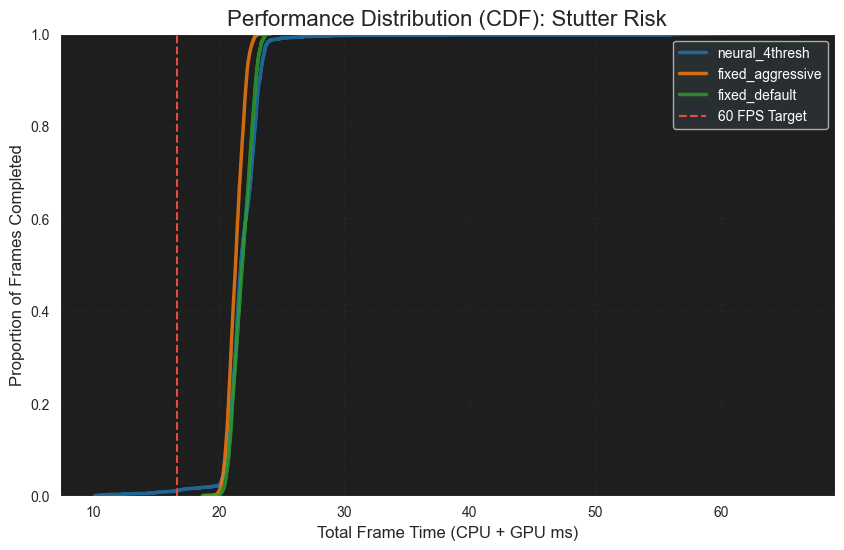

In [11]:
plt.figure(figsize=(10, 6))

for label in data['run_label'].unique():
    subset = data[data['run_label'] == label]
    # Total frame = CPU + GPU
    total_time = subset['cpu_ms'] + subset['gpu_ms']
    
    sns.ecdfplot(total_time, label=label, linewidth=2.5, alpha=0.8)

plt.axvline(FRAME_BUDGET_MS, color='#E74C3C', linestyle='--', label='60 FPS Target')
plt.title('Performance Distribution (CDF): Stutter Risk', fontsize=16)
plt.xlabel('Total Frame Time (CPU + GPU ms)', fontsize=12)
plt.ylabel('Proportion of Frames Completed', fontsize=12)
plt.legend(facecolor='#2D3436', labelcolor='white')

plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.3)
plt.show()


### 10. Spatial Delta Map: Localized Performance Gain


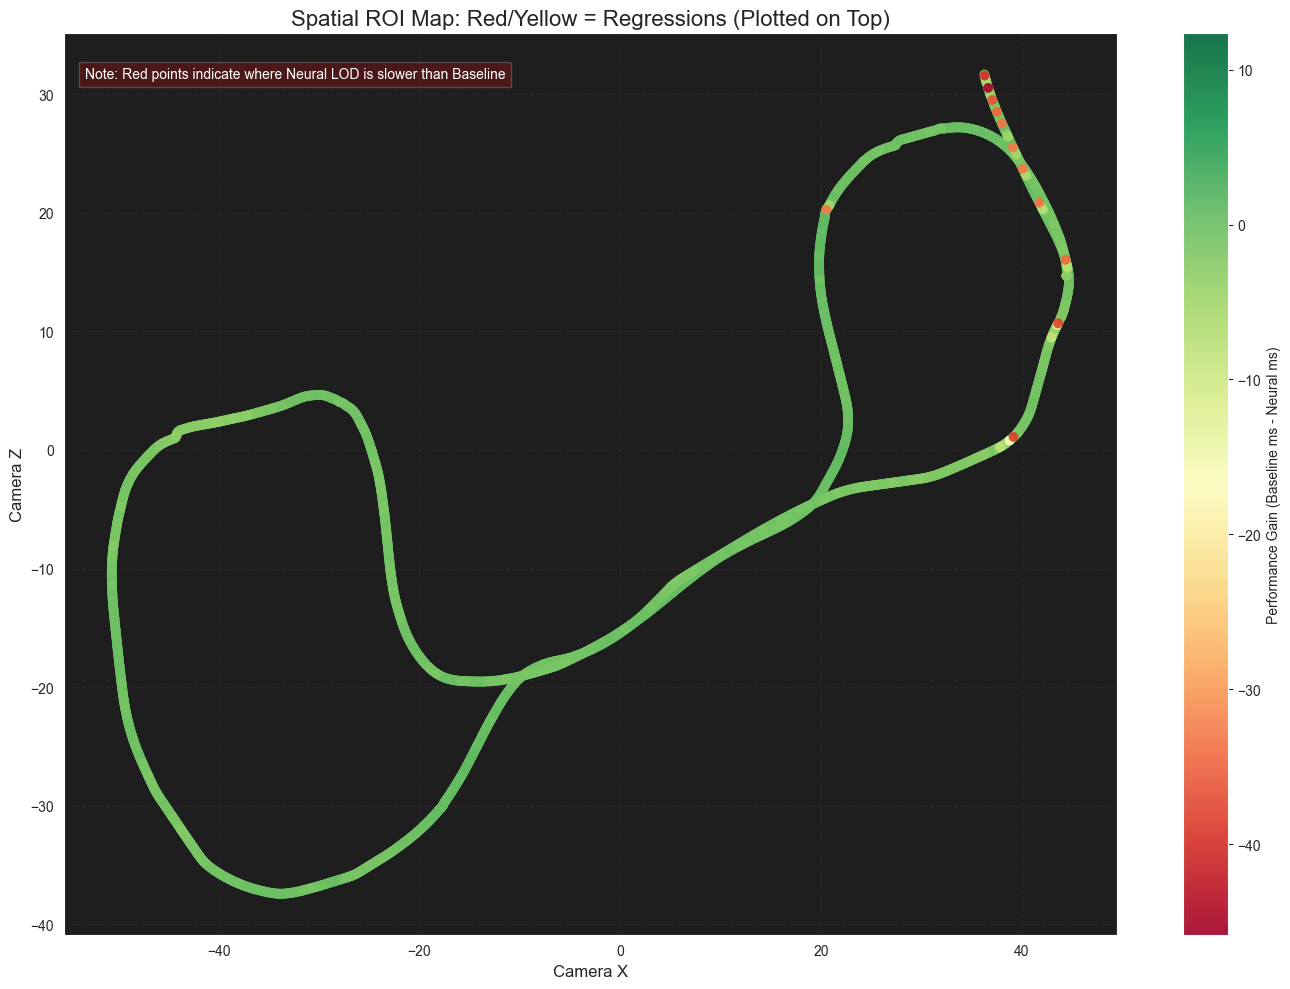

In [12]:
neural_path = data[data['run_label'] == 'neural_4thresh'].copy()
base_path = data[data['run_label'] == 'fixed_default'].copy()

# Merge to calculate local delta
spatial_merged = pd.merge(neural_path[['frame', 'cam_pos_x', 'cam_pos_z', 'cpu_ms', 'gpu_ms']], 
                          base_path[['frame', 'cpu_ms', 'gpu_ms']], 
                          on='frame', suffixes=('_neu', '_base'))

# Delta = Baseline Total Time - Neural Total Time (Positive = Neural Win)
spatial_merged['delta_ms'] = (spatial_merged['cpu_ms_base'] + spatial_merged['gpu_ms_base']) - \
                             (spatial_merged['cpu_ms_neu'] + spatial_merged['gpu_ms_neu'])

# SORT: We sort descending so that the lowest values (Red regressions) 
# are plotted LAST in the loop, ensuring they appear on top of the Green wins.
spatial_merged = spatial_merged.sort_values('delta_ms', ascending=False)

plt.figure(figsize=(14, 10))
sc = plt.scatter(spatial_merged['cam_pos_x'], spatial_merged['cam_pos_z'], 
                 c=spatial_merged['delta_ms'], cmap='RdYlGn', s=50, alpha=0.9,
                 edgecolors='none') # Removed edges for cleaner overlap

plt.colorbar(sc, label='Performance Gain (Baseline ms - Neural ms)')
plt.title('Spatial ROI Map: Red/Yellow = Regressions (Plotted on Top)', fontsize=16)
plt.xlabel('Camera X', fontsize=12)
plt.ylabel('Camera Z', fontsize=12)

plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.5)

# Add an annotation for clarity
plt.text(0.02, 0.95, 'Note: Red points indicate where Neural LOD is slower than Baseline', 
         transform=plt.gca().transAxes, color='white', bbox=dict(facecolor='red', alpha=0.2))

plt.tight_layout()
plt.show()
